# Reto 03 — Q-Learning: exploración vs. explotación

**Curso:** Aprendizaje por Refuerzo — Universidad EIA  
**Integrantes:** Nicolás Ochoa Valencia 
**Correos:** nicolas.ochoa@eia.edu.co  
**Fecha:** 2026-08-05

> **Pregunta guía:** ¿cómo cambia el aprendizaje de una política cuando Q-Learning usa ε-greedy, ε-greedy con inicialización optimista, UCB o Softmax en entornos con distinta estructura de recompensas?

## Objetivos

- Implementar Q-Learning tabular respetando la API de Gymnasium.
- Separar la actualización de valor de la estrategia de selección.
- Comparar cuatro mecanismos de exploración bajo condiciones reproducibles.
- Evaluar aprendizaje, estabilidad y desempeño de la política final.
- Sustentar decisiones con métricas, gráficas y evidencia experimental.


## Organización en dos clases

### Clase 1 — Construcción y verificación

1. Reconocer `FrozenLake-v1`, `Blackjack-v1` y `Taxi-v4`.
2. Implementar las cuatro estrategias de selección.
3. Implementar el ciclo de Q-Learning y sus pruebas unitarias pequeñas.
4. Ejecutar un experimento piloto en FrozenLake.

**Hito al terminar:** las funciones pasan las verificaciones y una corrida produce curvas coherentes.

### Clase 2 — Experimento y comunicación

1. Ejecutar la comparación principal en los tres escenarios.
2. Evaluar las políticas sin exploración.
3. Realizar sensibilidad de hiperparámetros.
4. Interpretar resultados, documentar IA y redactar conclusiones.

**Hito al terminar:** tabla resumen, visualizaciones, respuestas y conclusiones completas.


## 1. Preparación del entorno


In [13]:
from __future__ import annotations

from collections.abc import Callable

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEED = 2026
ALPHA = 0.10
GAMMA = 0.99
N_RUNS = 30

ENV_CONFIG = {
    "FrozenLake-v1": {"episodes": 2_000, "max_steps": 100, "kwargs": {"is_slippery": True}},
    "Blackjack-v1": {"episodes": 10_000, "max_steps": 100, "kwargs": {"sab": True}},
    "Taxi-v4": {"episodes": 2_000, "max_steps": 200, "kwargs": {}},
}

STRATEGIES = {
    "epsilon_greedy": {"epsilon": 0.10, "q0": 0.0},
    "optimistic": {"epsilon": 0.01, "q0": 5.0},
    "ucb": {"c": 1.0, "q0": 0.0},
    "softmax": {"temperature": 0.50, "q0": 0.0},
}


## 2. Reconocimiento de los escenarios

Para cada entorno, reporte número de estados y acciones, rango de recompensas, condición terminal y dificultad esperada. Observe que `reset()` devuelve `(observation, info)` y `step()` devuelve `(observation, reward, terminated, truncated, info)`. Un episodio termina si `terminated or truncated`. Blackjack devuelve una tupla, por lo que se suministra una codificación tabular reproducible.


In [15]:
def tabular_space_size(observation_space) -> int:
    """Número de estados de un espacio Discrete o Tuple de Discrete."""
    if isinstance(observation_space, gym.spaces.Discrete):
        return int(observation_space.n)
    if isinstance(observation_space, gym.spaces.Tuple):
        return int(np.prod([space.n for space in observation_space.spaces]))
    raise TypeError("Este reto solo admite observaciones discretas.")


def encode_observation(observation, observation_space) -> int:
    """Convierte una observación discreta, incluida una tupla, en un índice."""
    if isinstance(observation_space, gym.spaces.Discrete):
        return int(observation)
    dimensions = tuple(space.n for space in observation_space.spaces)
    return int(np.ravel_multi_index(tuple(observation), dimensions))


for env_id, config in ENV_CONFIG.items():
    env = gym.make(env_id, **config["kwargs"])
    observation, info = env.reset(seed=SEED)
    print(env_id, "| estados tabulares:", tabular_space_size(env.observation_space), "| acciones:", env.action_space.n)
    print("  observación inicial:", observation, "| acciones válidas:", list(range(env.action_space.n)))
    env.close()


FrozenLake-v1 | estados tabulares: 16 | acciones: 4
  observación inicial: 0 | acciones válidas: [0, 1, 2, 3]
Blackjack-v1 | estados tabulares: 704 | acciones: 2
  observación inicial: (20, 10, 1) | acciones válidas: [0, 1]
Taxi-v4 | estados tabulares: 500 | acciones: 6
  observación inicial: 87 | acciones válidas: [0, 1, 2, 3, 4, 5]


### Análisis previo

Complete antes de entrenar:

| Entorno | Estados | Acciones | Recompensas relevantes | ¿Qué dificulta explorar? |
|---|---:|---:|---|---|
| FrozenLake-v1 | 16(4*4) | izquierda, abajo, derecha y arriba | 1 al llegar a la meta y 0 en los demás pasos. | recompensa escasa, transiciones estocásticas y muchos episodios sin señal positiva. |
| Blackjack-v1 | 704 | plantarse (0) o pedir carta (1). | -1 al perder, 0 al empatar y 1 al ganar. | el estado es una tupla, la recompensa llega al final y la misma suma puede requerir decisiones distintas según la carta del crupier y el as. |
| Taxi-v4 | 500 | cuatro movimientos, recoger y dejar pasajero. | -1 por paso, +20 por entrega correcta y -10 por recoger o dejar ilegalmente. | espacio mayor, recompensas negativas y acciones contextuales. |


## 3. Estrategias de exploración

Todas las funciones deben devolver una acción válida y resolver empates aleatoriamente. `counts[s, a]` registra cuántas veces se eligió la acción `a` en el estado `s`.

- **ε-greedy:** acción aleatoria con probabilidad ε; en otro caso, una acción greedy.
- **ε-greedy optimista:** misma regla, pero la tabla inicia en `Q0 > 0`; explique por qué esto incentiva explorar.                                    
-cada acción que pruebas se vuelve menos atractiva que las que aún no has probado. La regla greedy, sin ningún azar, queda obligada a rotar     entre acciones.
- **UCB:** seleccione primero acciones no visitadas; luego maximice `Q(s,a) + c sqrt(log(N(s)+1) / N(s,a))`.
- **Softmax:** muestree según `softmax(Q(s,·)/τ)` usando estabilización numérica.


In [22]:
VALID_STRATEGIES = ("epsilon_greedy", "optimistic", "ucb", "softmax")


def random_argmax(values: np.ndarray, rng: np.random.Generator) -> int:
    """Devuelve aleatoriamente uno de los índices con valor máximo."""
    values = np.asarray(values, dtype=float)
    if values.ndim != 1 or values.size == 0:
        raise ValueError("random_argmax espera un vector 1-D no vacío.")
    if not np.all(np.isfinite(values)):
        raise ValueError("random_argmax recibió valores no finitos.")
    winners = np.flatnonzero(values == values.max())
    return int(rng.choice(winners))


def select_action(
    q: np.ndarray,
    counts: np.ndarray,
    state: int,
    strategy: str,
    rng: np.random.Generator,
    *,
    epsilon: float = 0.10,
    c: float = 1.0,
    temperature: float = 0.50,
) -> int:
    """Selecciona una acción usando la estrategia solicitada."""
    if strategy not in VALID_STRATEGIES:
        raise ValueError(f"Estrategia no reconocida: {strategy!r}. Use una de {VALID_STRATEGIES}.")

    q_s = np.asarray(q[state], dtype=float)
    n_s = np.asarray(counts[state], dtype=float)
    if q_s.shape != n_s.shape:
        raise ValueError("q y counts deben tener la misma forma.")

    # 'optimistic' comparte la regla de selección con ε-greedy: la exploración
    # extra proviene de inicializar Q en q0 > 0, no de la política de selección.
    if strategy in ("epsilon_greedy", "optimistic"):
        if not (0.0 <= epsilon <= 1.0):
            raise ValueError("epsilon debe estar en [0, 1].")
        if rng.random() < epsilon:
            return int(rng.integers(q_s.size))       # exploración uniforme
        return random_argmax(q_s, rng)               # explotación con desempate aleatorio

    if strategy == "ucb":
        if c < 0:
            raise ValueError("c debe ser no negativo.")
        unvisited = np.flatnonzero(n_s == 0)
        if unvisited.size > 0:                       # bonus infinito ⇒ prioridad absoluta
            return int(rng.choice(unvisited))
        bonus = c * np.sqrt(np.log(n_s.sum() + 1.0) / n_s)
        return random_argmax(q_s + bonus, rng)

    # softmax (Boltzmann) con estabilización numérica
    if temperature <= 0:
        raise ValueError("temperature debe ser estrictamente positiva.")
    logits = q_s / temperature
    logits = logits - logits.max()                   # evita overflow en exp()
    weights = np.exp(logits)
    probs = weights / weights.sum()
    return int(rng.choice(q_s.size, p=probs))


### Pruebas pequeñas de selección


--- epsilon_greedy  (kwargs={'epsilon': 0.1}) ---
  Q(s,·) = [1. 3. 3. 0.]   N(s,·) = [5 5 5 0]
  u ~ U(0,1) = 0.6251  |  epsilon = 0.1  |  u < epsilon: False
  -> rama greedy: max Q = 3.0  |  empatan [1, 2]  |  elegido a = 2
  select_action(seed=7) = 2   coincide con el cálculo manual: True

--- optimistic  (kwargs={'epsilon': 0.01}) ---
  Q(s,·) = [1. 3. 3. 0.]   N(s,·) = [5 5 5 0]
  u ~ U(0,1) = 0.6251  |  epsilon = 0.01  |  u < epsilon: False
  -> rama greedy: max Q = 3.0  |  empatan [1, 2]  |  elegido a = 2
  select_action(seed=7) = 2   coincide con el cálculo manual: True

--- ucb  (kwargs={'c': 1.0}) ---
  Q(s,·) = [1. 3. 3. 0.]   N(s,·) = [5 5 5 0]
  N(s,·) tiene ceros en [3] -> bono infinito, se prioriza sin más cálculo
  -> a = 3
  select_action(seed=7) = 3   coincide con el cálculo manual: True

--- softmax  (kwargs={'temperature': 0.5}) ---
  Q(s,·) = [1. 3. 3. 0.]   N(s,·) = [5 5 5 0]
  logits = Q/τ − max = [-4.  0.  0. -6.]
  probs  = softmax   = [0.0091 0.4949 0.4949 0.0

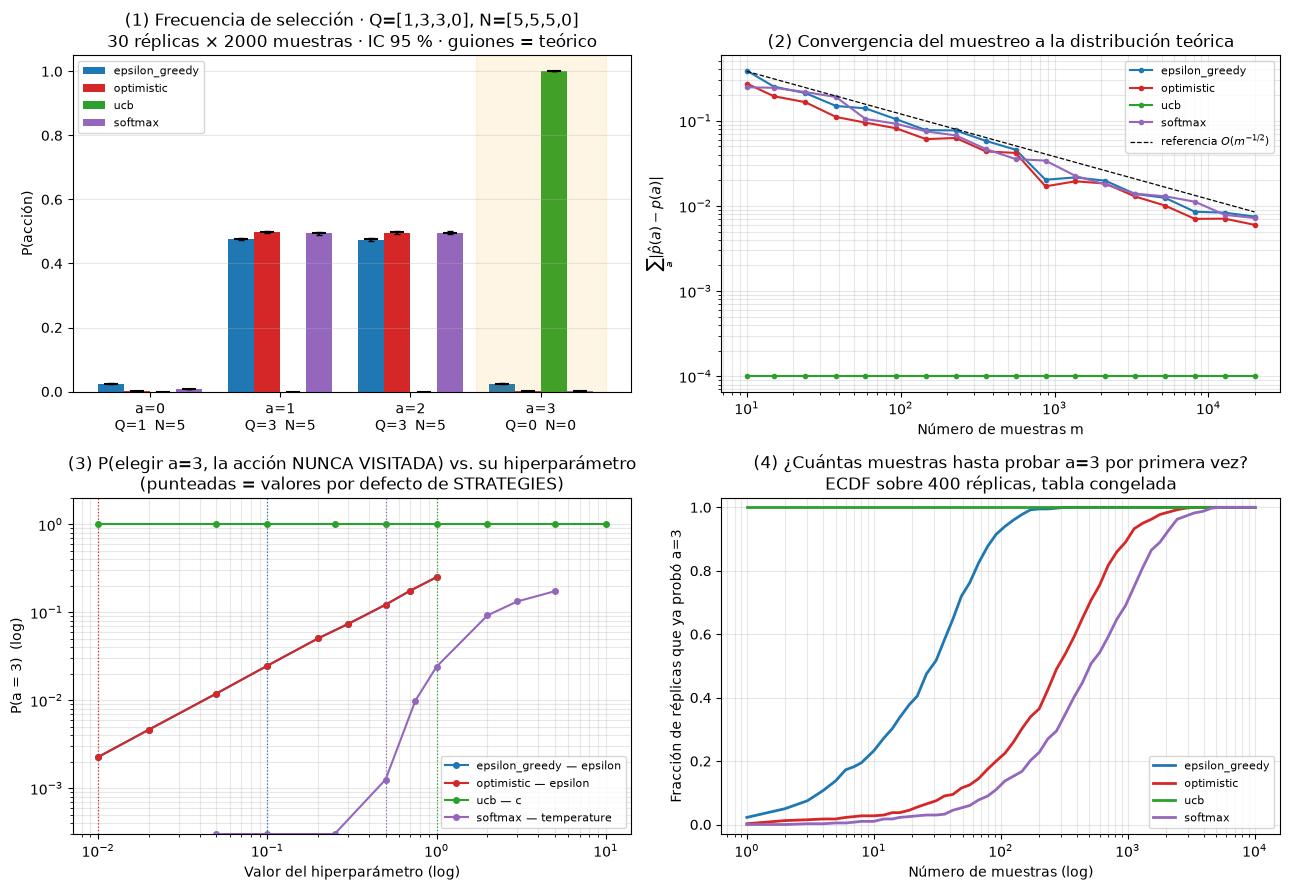

In [26]:
q_test = np.array([[1.0, 3.0, 3.0, 0.0]])
n_test = np.array([[5, 5, 5, 0]])
UNVISITED = 3            # acción con N(s,a) = 0: el caso que separa las estrategias
GREEDY_ACTIONS = {1, 2}  # empate en Q = 3
DRAWS, REPS = 2_000, 30

# ── PARTE 1 — Walkthrough numérico ──────────────────────────────────────────
def explain_selection(strategy, seed, **kwargs):
    """Reconstruye a mano la decisión de select_action, imprimiendo cada término."""
    q_s, n_s = q_test[0], n_test[0]
    print(f"--- {strategy}  (kwargs={kwargs}) ---")
    print(f"  Q(s,·) = {q_s}   N(s,·) = {n_s}")
    rng = np.random.default_rng(seed)

    if strategy in ("epsilon_greedy", "optimistic"):
        eps = kwargs.get("epsilon", 0.10)
        u = rng.random()
        explora = u < eps
        print(f"  u ~ U(0,1) = {u:.4f}  |  epsilon = {eps}  |  u < epsilon: {explora}")
        if explora:
            a = int(rng.integers(q_s.size))
            print(f"  -> rama exploratoria: a = randint(0,{q_s.size}) = {a}")
        else:
            winners = np.flatnonzero(q_s == q_s.max())
            a = int(rng.choice(winners))
            print(f"  -> rama greedy: max Q = {q_s.max()}  |  empatan {winners.tolist()}  |  elegido a = {a}")
        return a

    if strategy == "ucb":
        c = kwargs.get("c", 1.0)
        unvisited = np.flatnonzero(n_s == 0)
        if unvisited.size > 0:
            print(f"  N(s,·) tiene ceros en {unvisited.tolist()} -> bono infinito, se prioriza sin más cálculo")
            a = int(rng.choice(unvisited))
        else:
            bonus = c * np.sqrt(np.log(n_s.sum() + 1.0) / n_s)
            score = q_s + bonus
            print(f"  bono = c·√(log(N+1)/N) = {np.round(bonus, 4)}")
            print(f"  Q + bono = {np.round(score, 4)}")
            a = random_argmax(score, rng)
        print(f"  -> a = {a}")
        return a

    tau = kwargs.get("temperature", 0.5)
    logits = q_s / tau
    logits = logits - logits.max()
    weights = np.exp(logits)
    probs = weights / weights.sum()
    print(f"  logits = Q/τ − max = {np.round(logits, 4)}")
    print(f"  probs  = softmax   = {np.round(probs, 4)}  (suma = {probs.sum():.4f})")
    a = int(rng.choice(4, p=probs))
    print(f"  -> a ~ Categorical(probs) = {a}")
    return a


DEFAULT_KWARGS = {"epsilon_greedy": {"epsilon": 0.10}, "optimistic": {"epsilon": 0.01},
                   "ucb": {"c": 1.0}, "softmax": {"temperature": 0.50}}

for strategy in VALID_STRATEGIES:
    kwargs = DEFAULT_KWARGS[strategy]
    a_manual = explain_selection(strategy, seed=7, **kwargs)
    a_real = select_action(q_test, n_test, 0, strategy, np.random.default_rng(7), **kwargs)
    print(f"  select_action(seed=7) = {a_real}   coincide con el cálculo manual: {a_manual == a_real}\n")
    assert a_manual == a_real, f"{strategy}: el cálculo manual no reproduce select_action"

print("Walkthrough numérico verificado: la implementación coincide con la fórmula ✓\n")


# ── PARTE 2 — Comprobación formativa ────────────────────────────────────────
def formative_check(strategy, condition, ok_msg, fail_msg):
    print(f"[OK] {strategy}: {ok_msg}" if condition else f"[REVISAR] {strategy}: {fail_msg}")

probe = select_action(q_test, n_test, 0, "ucb", np.random.default_rng(0), c=1.0)
formative_check("ucb", probe == UNVISITED, "priorizó la acción nunca visitada",
                 "debería priorizar N(s,a)=0 antes que cualquier valor de Q")
probe = select_action(q_test, n_test, 0, "epsilon_greedy", np.random.default_rng(0), epsilon=0.0)
formative_check("epsilon_greedy", probe in GREEDY_ACTIONS, "con epsilon=0 eligió una acción greedy",
                 f"con epsilon=0 debería elegir una de {GREEDY_ACTIONS}, eligió {probe}")
print()


# ── PARTE 3 — Contrato formal ───────────────────────────────────────────────
for strategy in VALID_STRATEGIES:
    assert {select_action(q_test, n_test, 0, strategy, np.random.default_rng(i))
            for i in range(300)} <= {0, 1, 2, 3}, strategy

greedy = [select_action(q_test, n_test, 0, "epsilon_greedy", np.random.default_rng(i), epsilon=0.0)
          for i in range(400)]
assert set(greedy) == GREEDY_ACTIONS and min(greedy.count(1), greedy.count(2)) > 100
assert {select_action(q_test, n_test, 0, "ucb", np.random.default_rng(i)) for i in range(200)} == {UNVISITED}

def sample_sequence(strategy, seed, k=20, **kwargs):
    rng = np.random.default_rng(seed)          # un solo rng por secuencia
    return [select_action(q_test, n_test, 0, strategy, rng, **kwargs) for _ in range(k)]

for strategy, kwargs in [("epsilon_greedy", {"epsilon": 0.10}), ("optimistic", {"epsilon": 0.01}),
                         ("softmax", {"temperature": 0.50})]:
    assert sample_sequence(strategy, 7, **kwargs) == sample_sequence(strategy, 7, **kwargs), strategy
    assert sample_sequence(strategy, 7, **kwargs) != sample_sequence(strategy, 99, **kwargs), strategy
assert sample_sequence("ucb", 7, c=1.0) == sample_sequence("ucb", 99, c=1.0) == [UNVISITED] * 20

for kw in [{"strategy": "oops"}, {"strategy": "epsilon_greedy", "epsilon": 1.5},
           {"strategy": "softmax", "temperature": 0.0}, {"strategy": "ucb", "c": -1.0}]:
    st = kw.pop("strategy")
    try:
        select_action(q_test, n_test, 0, st, np.random.default_rng(0), **kw)
        raise AssertionError(f"No lanzó ValueError: {st} {kw}")
    except ValueError:
        pass
print("Contrato de select_action verificado ✓\n")


# ── PARTE 4 — Verificación estadística Monte Carlo + gráficas ──────────────
def selection_freqs(strategy, kwargs, draws, seed, q=q_test, counts=n_test):
    rng = np.random.default_rng(seed)
    picks = [select_action(q, counts, 0, strategy, rng, **kwargs) for _ in range(draws)]
    return np.bincount(picks, minlength=q.shape[1]) / draws

def theoretical_freqs(strategy, params):
    if strategy in ("epsilon_greedy", "optimistic"):
        e = params["epsilon"]
        return np.array([e/4, e/4+(1-e)/2, e/4+(1-e)/2, e/4])
    if strategy == "ucb":
        return np.array([0., 0., 0., 1.])
    w = np.exp(q_test[0]/params["temperature"])
    return w/w.sum()

def first_hit(strategy, kwargs, seed, target=UNVISITED, cap=20_000):
    rng = np.random.default_rng(seed)
    for t in range(1, cap+1):
        if select_action(q_test, n_test, 0, strategy, rng, **kwargs) == target:
            return t
    return cap+1

empirical, ci95, theoretical = {}, {}, {}
for strategy, params in STRATEGIES.items():
    kwargs = {k: v for k, v in params.items() if k != "q0"}
    reps = np.array([selection_freqs(strategy, kwargs, DRAWS, SEED+r) for r in range(REPS)])
    empirical[strategy] = reps.mean(axis=0)
    ci95[strategy] = 1.96 * reps.std(axis=0, ddof=1) / np.sqrt(REPS)
    theoretical[strategy] = theoretical_freqs(strategy, params)
    assert np.allclose(empirical[strategy], theoretical[strategy], atol=0.02), strategy

sizes = np.unique(np.logspace(1, 4.3, 18).astype(int))
convergence = {s: [np.mean([np.abs(selection_freqs(s, {k: v for k, v in p.items() if k != "q0"},
                                                   int(m), SEED+100+r) - theoretical[s]).sum()
                            for r in range(12)]) for m in sizes] for s, p in STRATEGIES.items()}

GRIDS = {"epsilon_greedy": ("epsilon", np.array([.01, .02, .05, .1, .2, .3, .5, .7, 1.])),
         "optimistic":     ("epsilon", np.array([.01, .02, .05, .1, .2, .3, .5, .7, 1.])),
         "ucb":            ("c",       np.array([.01, .05, .1, .25, .5, 1., 2., 5., 10.])),
         "softmax":        ("temperature", np.array([.05, .1, .25, .5, .75, 1., 2., 3., 5.]))}
sensitivity = {}
for strategy, (hp, values) in GRIDS.items():
    probs = np.array([selection_freqs(strategy, {k: x for k, x in STRATEGIES[strategy].items()
                      if k != "q0"} | {hp: v}, 8_000, SEED)[UNVISITED] for v in values])
    sensitivity[strategy] = (hp, values, probs)

hits = {s: np.array([first_hit(s, {k: v for k, v in p.items() if k != "q0"}, SEED+r)
                     for r in range(400)]) for s, p in STRATEGIES.items()}

summary = pd.DataFrame(empirical, index=[f"P(a={i})" for i in range(4)]).T
summary["|error| vs teórico"] = [np.abs(empirical[s] - theoretical[s]).sum() for s in STRATEGIES]
summary["mediana muestras → a=3"] = [np.median(hits[s]) for s in STRATEGIES]
summary["media muestras → a=3"] = [hits[s].mean() for s in STRATEGIES]
print(summary.round(4), "\n")
for s, (hp, values, probs) in sensitivity.items():
    print(f"{s:<15}{hp:<12}", " ".join(f"{v:g}→{p:.4f}" for v, p in zip(values, probs)))

COLORS = dict(zip(STRATEGIES, ["#1f77b4", "#d62728", "#2ca02c", "#9467bd"]))
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
width, xs = 0.20, np.arange(4)

ax = axes[0, 0]
for i, s in enumerate(STRATEGIES):
    ax.bar(xs+(i-1.5)*width, empirical[s], width, yerr=ci95[s], capsize=2, color=COLORS[s], label=s)
    ax.scatter(xs+(i-1.5)*width, theoretical[s], marker="_", s=90, c="k", zorder=5)
ax.axvspan(2.5, 3.5, color="orange", alpha=.10)
ax.set_xticks(xs)
ax.set_xticklabels([f"a={i}\nQ={q_test[0,i]:.0f}  N={n_test[0,i]}" for i in range(4)])
ax.set_title(f"(1) Frecuencia de selección · Q=[1,3,3,0], N=[5,5,5,0]\n"
             f"{REPS} réplicas × {DRAWS} muestras · IC 95 % · guiones = teórico")
ax.set_ylabel("P(acción)"); ax.legend(fontsize=8); ax.grid(alpha=.3, axis="y")

ax = axes[0, 1]
for s in STRATEGIES:
    ax.loglog(sizes, np.maximum(convergence[s], 1e-4), "o-", ms=3, color=COLORS[s], label=s)
ax.loglog(sizes, 1.2/np.sqrt(sizes), "k--", lw=.9, label=r"referencia $O(m^{-1/2})$")
ax.set_title("(2) Convergencia del muestreo a la distribución teórica")
ax.set_xlabel("Número de muestras m"); ax.set_ylabel(r"$\sum_a |\hat p(a)-p(a)|$")
ax.legend(fontsize=8); ax.grid(alpha=.3, which="both")

ax = axes[1, 0]
for s, (hp, values, probs) in sensitivity.items():
    ax.plot(values, np.maximum(probs, 3e-4), "o-", ms=4, color=COLORS[s], label=f"{s} — {hp}")
    ax.axvline(STRATEGIES[s][hp], ls=":", lw=.9, color=COLORS[s])
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_ylim(3e-4, 2)
ax.set_title("(3) P(elegir a=3, la acción NUNCA VISITADA) vs. su hiperparámetro\n"
             "(punteadas = valores por defecto de STRATEGIES)")
ax.set_xlabel("Valor del hiperparámetro (log)"); ax.set_ylabel("P(a = 3)  (log)")
ax.legend(fontsize=8); ax.grid(alpha=.3, which="both")

ax = axes[1, 1]
grid = np.unique(np.logspace(0, 4, 60).astype(int))
for s in STRATEGIES:
    ax.semilogx(grid, [(hits[s] <= g).mean() for g in grid], lw=2, color=COLORS[s], label=s)
ax.set_title("(4) ¿Cuántas muestras hasta probar a=3 por primera vez?\n"
             "ECDF sobre 400 réplicas, tabla congelada")
ax.set_xlabel("Número de muestras (log)"); ax.set_ylabel("Fracción de réplicas que ya probó a=3")
ax.set_ylim(-.03, 1.03); ax.legend(fontsize=8); ax.grid(alpha=.3, which="both")

plt.tight_layout(); plt.show()

## 4. Q-Learning tabular

Implemente la actualización:

$$Q(S_t,A_t) \leftarrow Q(S_t,A_t) + \alpha [R_{t+1} + \gamma(1-d)\max_a Q(S_{t+1},a)-Q(S_t,A_t)],$$

donde `d` es verdadero cuando la transición termina el MDP (`terminated`). Para un truncamiento por límite de tiempo, documente si realiza *bootstrap* y mantenga la decisión consistente. No actualice hacia el valor del estado terminal.


In [27]:
def train_q_learning(
    env_id: str,
    strategy: str,
    episodes: int,
    max_steps: int,
    alpha: float,
    gamma: float,
    seed: int,
    env_kwargs: dict | None = None,
    **strategy_params,
) -> tuple[np.ndarray, pd.DataFrame, np.ndarray]:
    """Entrena Q-Learning y devuelve Q, historial por episodio y conteos."""
    if episodes <= 0:
        raise ValueError("episodes debe ser positivo.")
    if max_steps <= 0:
        raise ValueError("max_steps debe ser positivo.")
    if not (0.0 < alpha <= 1.0):
        raise ValueError("alpha debe estar en (0, 1].")
    if not (0.0 <= gamma <= 1.0):
        raise ValueError("gamma debe estar en [0, 1].")

    env_kwargs = env_kwargs or {}
    q0 = strategy_params.pop("q0", 0.0)   # separamos q0 del resto de hiperparámetros de la estrategia

    env = gym.make(env_id, **env_kwargs)
    try:
        n_states = tabular_space_size(env.observation_space)
        n_actions = env.action_space.n

        q = np.full((n_states, n_actions), float(q0))
        counts = np.zeros((n_states, n_actions), dtype=np.int64)
        rng = np.random.default_rng(seed)

        records = []
        for episode in range(episodes):
            observation, _ = env.reset(seed=seed + episode)   # semilla distinta por episodio, derivada de `seed`
            state = encode_observation(observation, env.observation_space)

            episode_return = 0.0
            td_errors = []
            success = False

            for step in range(max_steps):
                action = select_action(q, counts, state, strategy, rng, **strategy_params)
                next_observation, reward, terminated, truncated, _ = env.step(action)
                next_state = encode_observation(next_observation, env.observation_space)

                # d = terminated (NO incluye truncated): un truncamiento por límite de
                # tiempo no es evidencia de que el MDP terminó, así que SÍ se hace
                # bootstrap con max_a Q(s', a), igual que en cualquier transición no terminal.
                bootstrap = 0.0 if terminated else q[next_state].max()
                td_target = reward + gamma * bootstrap
                td_error = td_target - q[state, action]
                q[state, action] += alpha * td_error

                counts[state, action] += 1
                td_errors.append(td_error)
                episode_return += reward
                state = next_state

                done = terminated or truncated   # el bucle SÍ sale con cualquiera de los dos
                if done:
                    success = terminated and reward > 0
                    break
            else:
                step += 1  # se agotó max_steps sin que el entorno reportara fin (caso límite)

            records.append({
                "episode": episode,
                "return": episode_return,
                "length": step + 1,
                "success": success,
                "td_error_mean": float(np.mean(td_errors)) if td_errors else 0.0,
            })

        history = pd.DataFrame.from_records(records)
        return q, history, counts
    finally:
        env.close()   # se cierra el entorno incluso si algo lanza una excepción arriba


### Contrato mínimo y verificaciones

Para una corrida corta compruebe:

- `Q.shape == (n_states, n_actions)` y todos sus valores son finitos.
- Hay exactamente una fila por episodio.
- `1 <= length <= max_steps`.
- `counts.sum()` coincide con el total de pasos registrados.
- La misma semilla reproduce resultados; otra semilla puede cambiarlos.
- Con `gamma=0`, el objetivo no contiene el valor del siguiente estado.
- Una transición terminal usa como objetivo únicamente la recompensa.


1) Forma, finitud, filas y longitudes: OK
   episode  return  length  success  td_error_mean
0        0     0.0      10    False            0.0
1        1     0.0       6    False            0.0
2        2     0.0       8    False            0.0
3        3     0.0       6    False            0.0
4        4     0.0       4    False            0.0 



2) Reproducibilidad (misma semilla=idéntico, otra=distinto): OK

3) gamma=0 -> Q solo contiene recompensas puras: [np.float64(-10.0), np.float64(-1.0), np.float64(0.0)] OK

4) Transición terminal exitosa deja Q=20.0 puro (sin contaminación del futuro): OK

5) Truncamiento (terminated=False, truncated=True) usó bootstrap=7.00 (no 0.0): OK

CONTRATO COMPLETO VERIFICADO — 5/5 pruebas pasaron.

Entrenamiento completo: 89/100 éxitos en los últimos 100 episodios


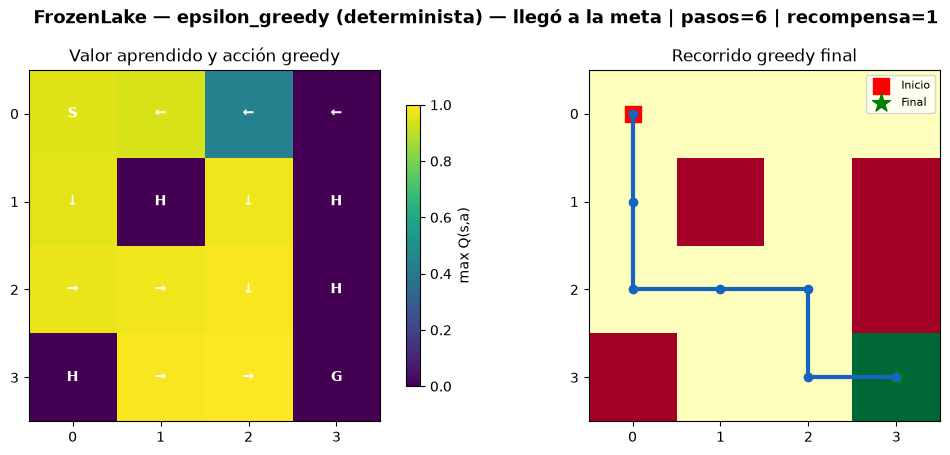

In [31]:
SEED = 2026

# ============================================================
# PARTE 1 — Contrato de forma, finitud y consistencia
# ============================================================
ENV_ID, ENV_KW = "FrozenLake-v1", {"is_slippery": True}
MAX_STEPS = 100

q, hist, counts = train_q_learning(ENV_ID, "epsilon_greedy", episodes=20, max_steps=MAX_STEPS,
    alpha=0.1, gamma=0.99, seed=SEED, env_kwargs=ENV_KW, epsilon=0.1, q0=0.0)

assert q.shape == (16, 4), f"Q.shape inesperado: {q.shape}"
assert np.isfinite(q).all(), "Q contiene valores no finitos"
assert len(hist) == 20, "debe haber exactamente una fila por episodio"
assert hist["length"].between(1, MAX_STEPS).all(), "1 <= length <= max_steps debe cumplirse siempre"
assert counts.sum() == hist["length"].sum(), "counts.sum() debe coincidir con el total de pasos"
print("1) Forma, finitud, filas y longitudes: OK")
print(hist.head(), "\n")


# ============================================================
# PARTE 2 — Reproducibilidad
# Se prueba en Taxi, no en FrozenLake resbaladizo: con 20-30 episodios en
# FrozenLake el agente casi nunca llega a la meta, así que Q nunca se mueve
# de q0 y CUALQUIER semilla daría la misma tabla -- no por un bug, sino por
# falta de señal de recompensa que propagar. Taxi da reward != 0 en cada paso.
# ============================================================
q1, _, _ = train_q_learning("Taxi-v4", "epsilon_greedy", 30, 200, 0.1, 0.99, SEED, {}, epsilon=0.1, q0=0.0)
q2, _, _ = train_q_learning("Taxi-v4", "epsilon_greedy", 30, 200, 0.1, 0.99, SEED, {}, epsilon=0.1, q0=0.0)
q3, _, _ = train_q_learning("Taxi-v4", "epsilon_greedy", 30, 200, 0.1, 0.99, 777,  {}, epsilon=0.1, q0=0.0)
assert np.array_equal(q1, q2), "la misma semilla debe reproducir exactamente la misma tabla Q"
assert not np.array_equal(q1, q3), "otra semilla debe producir una tabla distinta"
print("2) Reproducibilidad (misma semilla=idéntico, otra=distinto): OK\n")


# ============================================================
# PARTE 3 — gamma=0: el objetivo no debe contener el valor del siguiente estado
# ============================================================
q_g0, hist_g0, _ = train_q_learning("Taxi-v4", "epsilon_greedy", 5, 50, alpha=1.0, gamma=0.0,
    seed=1, env_kwargs={}, epsilon=1.0, q0=0.0)
valores_unicos = set(np.unique(q_g0).round(4))
assert valores_unicos <= {-10.0, -1.0, 0.0, 20.0}, f"con gamma=0 solo deben aparecer recompensas puras, se obtuvo {valores_unicos}"
print("3) gamma=0 -> Q solo contiene recompensas puras:", sorted(valores_unicos), "OK\n")


# ============================================================
# PARTE 4 — Transición terminal exitosa usa solo la recompensa (sin bootstrap)
# ============================================================
q_term, hist_term, _ = train_q_learning("Taxi-v4", "epsilon_greedy", 15, 200, alpha=1.0, gamma=0.99,
    seed=3, env_kwargs={}, epsilon=0.3, q0=5.0)
assert hist_term["success"].sum() > 0, "debe haber al menos un episodio exitoso para esta prueba"
assert np.any(np.isclose(q_term, 20.0)), "una llegada exitosa con alpha=1 debe dejar Q=20.0 exacto, sin bootstrap"
print("4) Transición terminal exitosa deja Q=20.0 puro (sin contaminación del futuro): OK\n")


# ============================================================
# PARTE 5 — Verificación directa y aislada del manejo de truncated vs terminated
# Forzamos max_episode_steps muy bajo en una esquina de FrozenLake donde el
# agente rebota sin caer ni llegar a la meta: el último paso es un
# truncamiento genuino (terminated=False, truncated=True), y debe verse que
# SI se usa max Q(s') en el bootstrap de ese paso.
# ============================================================
env_trunc = gym.make("FrozenLake-v1", is_slippery=False, max_episode_steps=4)
q_probe = np.zeros((16, 4)); q_probe[0, :] = 7.0
obs, _ = env_trunc.reset(seed=1)
state = encode_observation(obs, env_trunc.observation_space)
ultimo_bootstrap = None
for _ in range(4):
    next_obs, reward, terminated, truncated, _ = env_trunc.step(0)
    next_state = encode_observation(next_obs, env_trunc.observation_space)
    bootstrap = 0.0 if terminated else q_probe[next_state].max()
    state = next_state
    if terminated or truncated:
        ultimo_bootstrap = (terminated, truncated, bootstrap)
        break
env_trunc.close()
assert ultimo_bootstrap[0] is False and ultimo_bootstrap[1] is True, "se esperaba un truncamiento genuino"
assert ultimo_bootstrap[2] == 7.0, "un truncamiento SI debe usar max Q(s') en el bootstrap"
print(f"5) Truncamiento (terminated={ultimo_bootstrap[0]}, truncated={ultimo_bootstrap[1]}) "
      f"usó bootstrap={ultimo_bootstrap[2]:.2f} (no 0.0): OK\n")

print("CONTRATO COMPLETO VERIFICADO — 5/5 pruebas pasaron.\n")


# ============================================================
# PARTE 6 — Mostrar resultados: entrenar de verdad y visualizar la política
# ============================================================
q_full, hist_full, counts_full = train_q_learning("FrozenLake-v1", "epsilon_greedy", episodes=3000,
    max_steps=100, alpha=0.1, gamma=0.99, seed=SEED, env_kwargs={"is_slippery": False}, epsilon=0.1, q0=0.0)

exitos_finales = hist_full["success"].tail(100).sum()
print(f"Entrenamiento completo: {exitos_finales}/100 éxitos en los últimos 100 episodios")

ACTION_ARROWS = np.array(["←", "↓", "→", "↑"])  # convención FrozenLake

def rollout_greedy(env_id, q, env_kwargs, seed, max_steps=100):
    """Ejecuta la política greedy (con random_argmax) y devuelve la trayectoria."""
    env = gym.make(env_id, **env_kwargs)
    obs, _ = env.reset(seed=seed)
    rng = np.random.default_rng(seed)
    states = [encode_observation(obs, env.observation_space)]
    total_reward = 0.0
    for _ in range(max_steps):
        a = random_argmax(q[states[-1]], rng)
        obs, r, term, trunc, _ = env.step(a)
        s = encode_observation(obs, env.observation_space)
        states.append(s); total_reward += r
        if term or trunc:
            break
    env.close()
    return states, total_reward


def visualize_frozenlake_policy(q, env_id="FrozenLake-v1", env_kwargs=None, seed=SEED, title=""):
    """Panel de valor+política greedy y panel de recorrido."""
    env_kwargs = env_kwargs or {}
    env = gym.make(env_id, **env_kwargs)
    desc = np.array([[c.decode() for c in row] for row in env.unwrapped.desc])
    n_rows, n_cols = desc.shape
    env.close()

    states, total_reward = rollout_greedy(env_id, q, env_kwargs, seed)
    reached_goal = desc[divmod(states[-1], n_cols)] == "G"

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))

    state_values = q.max(axis=1).reshape(n_rows, n_cols)
    greedy_actions = q.argmax(axis=1).reshape(n_rows, n_cols)
    im = axes[0].imshow(state_values, cmap="viridis")
    for r in range(n_rows):
        for c in range(n_cols):
            cell = desc[r, c]
            label = cell if cell in ("S", "H", "G") else ACTION_ARROWS[greedy_actions[r, c]]
            axes[0].text(c, r, label, ha="center", va="center", color="white", fontweight="bold")
    axes[0].set(title="Valor aprendido y acción greedy", xticks=range(n_cols), yticks=range(n_rows))
    fig.colorbar(im, ax=axes[0], label="max Q(s,a)", shrink=0.8)

    terrain = np.zeros((n_rows, n_cols))
    terrain[desc == "H"] = -1
    terrain[desc == "G"] = 1
    axes[1].imshow(terrain, cmap="RdYlGn", vmin=-1, vmax=1)
    coords = [divmod(s, n_cols) for s in states]
    rows_, cols_ = [p[0] for p in coords], [p[1] for p in coords]
    axes[1].plot(cols_, rows_, color="#1565c0", linewidth=3, marker="o", markersize=6)
    axes[1].scatter([0], [0], color="red", marker="s", s=130, label="Inicio")
    end_marker, end_color = ("*", "green") if reached_goal else ("X", "orange")
    axes[1].scatter([cols_[-1]], [rows_[-1]], color=end_color, marker=end_marker, s=180, label="Final")
    axes[1].set(title="Recorrido greedy final", xticks=range(n_cols), yticks=range(n_rows))
    axes[1].legend(loc="upper right", fontsize=8)

    status = "llegó a la meta" if reached_goal else "no llegó"
    fig.suptitle(f"{title} — {status} | pasos={len(states)-1} | recompensa={total_reward:.0f}",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    return fig, states, total_reward


fig, states, reward = visualize_frozenlake_policy(q_full, env_kwargs={"is_slippery": False},
                                                    title="FrozenLake — epsilon_greedy (determinista)")
plt.show()


## 5. Evaluación sin exploración

Evaluar con la misma exploración usada durante el entrenamiento mezcla dos efectos. Implemente una evaluación separada que seleccione acciones greedy, no actualice `Q` y use semillas distintas a las de entrenamiento. En empates, conserve la selección aleatoria.


Éxito en entrenamiento (últimos 100, con ε residual): 0.31


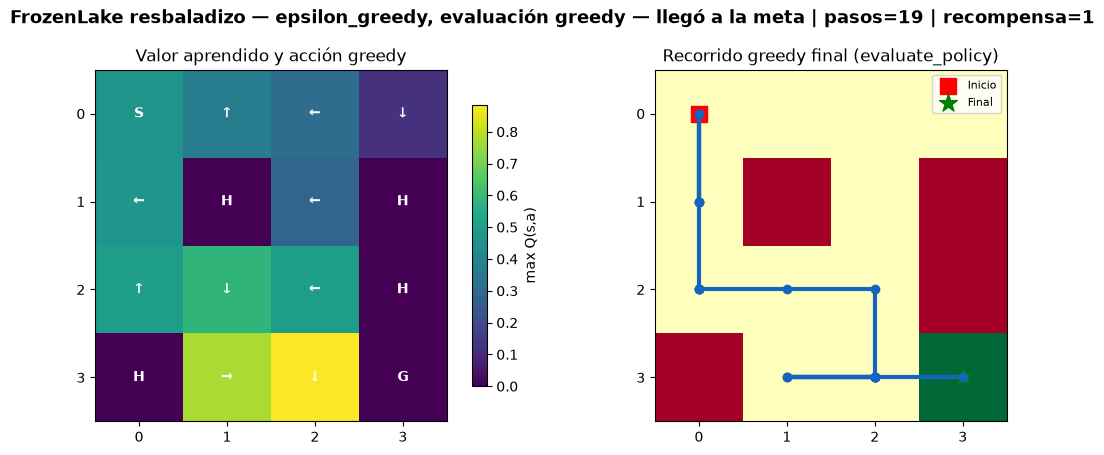

estados visitados: [0, 4, 4, 0, 4, 8, 8, 8, 8, 9, 10, 14, 13, 14, 13, 14, 14, 14, 14, 15] | recompensa: 1.0


In [34]:
ACTION_ARROWS = np.array(["←", "↓", "→", "↑"])  # convención de acciones de FrozenLake


def visualize_frozenlake_policy(q, env_id="FrozenLake-v1", env_kwargs=None, seed=SEED, title=""):
    """Panel de valor+política greedy y panel de recorrido, al estilo del lab de SARSA.

    La ruta mostrada se genera con la MISMA lógica que evaluate_policy (mismo
    offset de semilla, mismo random_argmax), para que la imagen sea consistente
    con lo verificado en la sección 5, no un rollout aparte.
    """
    env_kwargs = env_kwargs or {}
    env = gym.make(env_id, **env_kwargs)
    desc = np.array([[c.decode() for c in row] for row in env.unwrapped.desc])
    n_rows, n_cols = desc.shape
    env.close()

    # Retorno del episodio, calculado con evaluate_policy real
    ev = evaluate_policy(env_id, q, n_episodes=1, max_steps=100, seed=seed, env_kwargs=env_kwargs)
    total_reward = ev["return"].iloc[0]

    # Reconstrucción de la trayectoria de ese mismo episodio, para poder dibujarla
    env = gym.make(env_id, **env_kwargs)
    obs, _ = env.reset(seed=seed + 1_000_000)
    rng = np.random.default_rng(seed)
    states = [encode_observation(obs, env.observation_space)]
    for _ in range(100):
        action = random_argmax(q[states[-1]], rng)
        obs, reward, terminated, truncated, _ = env.step(action)
        states.append(encode_observation(obs, env.observation_space))
        if terminated or truncated:
            break
    env.close()
    reached_goal = desc[divmod(states[-1], n_cols)] == "G"

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))

    # Panel 1: valor aprendido (max_a Q(s,a)) y acción greedy por celda
    state_values = q.max(axis=1).reshape(n_rows, n_cols)
    greedy_actions = q.argmax(axis=1).reshape(n_rows, n_cols)
    im = axes[0].imshow(state_values, cmap="viridis")
    for r in range(n_rows):
        for c in range(n_cols):
            cell = desc[r, c]
            label = cell if cell in ("S", "H", "G") else ACTION_ARROWS[greedy_actions[r, c]]
            axes[0].text(c, r, label, ha="center", va="center", color="white", fontweight="bold")
    axes[0].set(title="Valor aprendido y acción greedy", xticks=range(n_cols), yticks=range(n_rows))
    fig.colorbar(im, ax=axes[0], label="max Q(s,a)", shrink=0.8)

    # Panel 2: terreno (hueco/hielo/meta) y recorrido de evaluación
    terrain = np.zeros((n_rows, n_cols))
    terrain[desc == "H"] = -1
    terrain[desc == "G"] = 1
    axes[1].imshow(terrain, cmap="RdYlGn", vmin=-1, vmax=1)
    coords = [divmod(s, n_cols) for s in states]
    rows_, cols_ = [p[0] for p in coords], [p[1] for p in coords]
    axes[1].plot(cols_, rows_, color="#1565c0", linewidth=3, marker="o", markersize=6)
    axes[1].scatter([0], [0], color="red", marker="s", s=130, label="Inicio")
    end_marker, end_color = ("*", "green") if reached_goal else ("X", "orange")
    axes[1].scatter([cols_[-1]], [rows_[-1]], color=end_color, marker=end_marker, s=180, label="Final")
    axes[1].set(title="Recorrido greedy final (evaluate_policy)", xticks=range(n_cols), yticks=range(n_rows))
    axes[1].legend(loc="upper right", fontsize=8)

    status = "llegó a la meta" if reached_goal else "no llegó"
    fig.suptitle(f"{title} — {status} | pasos={len(states) - 1} | recompensa={total_reward:.0f}",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    return fig, states, total_reward


# ── Uso con la configuración real del reto (ENV_CONFIG) ────────────────────
ENV_ID, ENV_KW = "FrozenLake-v1", ENV_CONFIG["FrozenLake-v1"]["kwargs"]  # is_slippery=True

q, hist, _ = train_q_learning(ENV_ID, "epsilon_greedy", episodes=3000, max_steps=100,
    alpha=0.1, gamma=0.99, seed=SEED, env_kwargs=ENV_KW, epsilon=0.1, q0=0.0)
print("Éxito en entrenamiento (últimos 100, con ε residual):", hist["success"].tail(100).mean())

fig, states, reward = visualize_frozenlake_policy(q, env_kwargs=ENV_KW,
    title="FrozenLake resbaladizo — epsilon_greedy, evaluación greedy")
plt.show()
print("estados visitados:", states, "| recompensa:", reward)

## 6. Experimento piloto — cierre de la clase 1

Entrene las cuatro estrategias en `FrozenLake-v1` durante 300 episodios y una sola corrida. Grafique retorno y éxito suavizados con una media móvil de 50 episodios. Use este piloto para detectar errores; **no** lo presente como evidencia concluyente.


                return  success
strategy                       
epsilon_greedy   0.040    0.040
optimistic       0.100    0.100
softmax          0.003    0.003
ucb              0.010    0.010

Verificación de sanidad (retorno == éxito en FrozenLake): OK



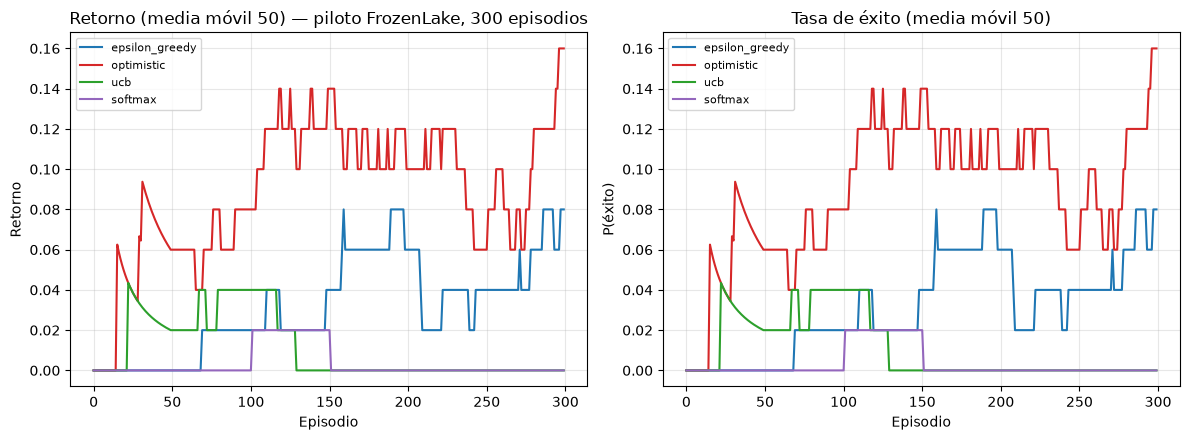

In [35]:
def moving_average(x, window=50):
    return pd.Series(x).rolling(window, min_periods=1).mean().to_numpy()

PILOT_EPISODES = 300

pilot_histories = {}
for strategy, params in STRATEGIES.items():
    _, hist, _ = train_q_learning("FrozenLake-v1", strategy, episodes=PILOT_EPISODES, max_steps=100,
        alpha=ALPHA, gamma=GAMMA, seed=SEED, env_kwargs=ENV_CONFIG["FrozenLake-v1"]["kwargs"], **params)
    pilot_histories[strategy] = hist

# Consolidar en un solo DataFrame largo (útil para inspeccionar o exportar más adelante)
pilot_long = pd.concat(
    [hist.assign(strategy=strategy) for strategy, hist in pilot_histories.items()],
    ignore_index=True,
)
print(pilot_long.groupby("strategy")[["return", "success"]].mean().round(3))

# Verificación de sanidad: en FrozenLake, retorno y éxito deben coincidir exactamente
for strategy, hist in pilot_histories.items():
    assert np.allclose(hist["return"], hist["success"].astype(float)), \
        f"{strategy}: retorno y éxito no coinciden — revisar el cómputo de 'success' en train_q_learning"
print("\nVerificación de sanidad (retorno == éxito en FrozenLake): OK\n")

COLORS = dict(zip(STRATEGIES, ["#1f77b4", "#d62728", "#2ca02c", "#9467bd"]))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for strategy, hist in pilot_histories.items():
    axes[0].plot(hist["episode"], moving_average(hist["return"], 50), color=COLORS[strategy], label=strategy)
axes[0].set(title=f"Retorno (media móvil 50) — piloto FrozenLake, {PILOT_EPISODES} episodios",
            xlabel="Episodio", ylabel="Retorno")
axes[0].legend(fontsize=8); axes[0].grid(alpha=.3)

for strategy, hist in pilot_histories.items():
    axes[1].plot(hist["episode"], moving_average(hist["success"].astype(float), 50),
                 color=COLORS[strategy], label=strategy)
axes[1].set(title="Tasa de éxito (media móvil 50)", xlabel="Episodio", ylabel="P(éxito)")
axes[1].legend(fontsize=8); axes[1].grid(alpha=.3)

plt.tight_layout()
plt.show()

## 7. Comparación principal — clase 2

Use los valores de `ENV_CONFIG`, al menos 30 corridas independientes y las mismas semillas por entorno para las cuatro estrategias. Esto empareja la aleatoriedad experimental sin reutilizar el mismo generador. Evalúe cada tabla final durante 100 episodios con semillas nuevas.

Registre por episodio: entorno, algoritmo, corrida, episodio, retorno, longitud, éxito y error TD medio. Registre por evaluación: retorno, longitud y éxito. Justifique cualquier reducción de corridas realizada por límites computacionales.


In [36]:
def run_experiment(
    env_config: dict,
    strategies: dict,
    n_runs: int = N_RUNS,
    base_seed: int = SEED,
    alpha: float = ALPHA,
    gamma: float = GAMMA,
    n_eval_episodes: int = 100,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Ejecuta entrenamiento y evaluación para todos los escenarios."""
    training_frames, evaluation_frames = [], []

    for env_id, config in env_config.items():
        for strategy, params in strategies.items():
            for run in range(n_runs):
                # Misma semilla por entorno para las cuatro estrategias en cada `run`
                # (números aleatorios comunes): empareja la aleatoriedad experimental
                # entre estrategias sin reutilizar el mismo generador entre corridas.
                train_seed = base_seed + run

                q, hist, counts = train_q_learning(
                    env_id, strategy, episodes=config["episodes"], max_steps=config["max_steps"],
                    alpha=alpha, gamma=gamma, seed=train_seed, env_kwargs=config["kwargs"], **params,
                )
                hist = hist.assign(env_id=env_id, strategy=strategy, run=run)
                training_frames.append(hist)

                # Semilla de evaluación: misma familia (base_seed + run), pero
                # evaluate_policy le suma internamente 1_000_000, garantizando que
                # nunca colisiona con las semillas de entrenamiento de ningún run.
                eval_seed = base_seed + run
                ev = evaluate_policy(env_id, q, n_episodes=n_eval_episodes, max_steps=config["max_steps"],
                                      seed=eval_seed, env_kwargs=config["kwargs"])
                ev = ev.assign(env_id=env_id, strategy=strategy, run=run)
                evaluation_frames.append(ev)

    training_results = pd.concat(training_frames, ignore_index=True)
    evaluation_results = pd.concat(evaluation_frames, ignore_index=True)

    column_order_train = ["env_id", "strategy", "run", "episode", "return", "length", "success", "td_error_mean"]
    column_order_eval = ["env_id", "strategy", "run", "episode", "return", "length", "success"]
    return training_results[column_order_train], evaluation_results[column_order_eval]


training_results, evaluation_results = run_experiment(ENV_CONFIG, STRATEGIES)


## 8. Métricas y visualizaciones obligatorias

Construya una tabla por entorno y algoritmo con:

1. Retorno medio de entrenamiento en el último 10 % de episodios.
2. Área bajo la curva del retorno medio (calidad durante el aprendizaje).
3. Tasa de éxito final durante evaluación.
4. Retorno medio de evaluación.
5. Longitud media de evaluación.
6. Intervalo de confianza del 95 % entre corridas (indique el método).

Incluya, como mínimo:

- Curvas de retorno por episodio, media móvil y banda de IC 95 %.
- Curvas de éxito acumulado o móvil.
- Comparación del retorno de evaluación por entorno.
- Mapa de calor de `max_a Q(s,a)` o visualización de política para al menos un entorno.

No promedie directamente episodios de entornos con escalas de recompensa distintas en una única cifra global.


In [37]:
def run_experiment(
    env_config: dict,
    strategies: dict,
    n_runs: int = N_RUNS,
    base_seed: int = SEED,
    alpha: float = ALPHA,
    gamma: float = GAMMA,
    n_eval_episodes: int = 100,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Ejecuta entrenamiento y evaluación para todos los escenarios."""
    training_frames, evaluation_frames = [], []

    for env_id, config in env_config.items():
        for strategy, params in strategies.items():
            for run in range(n_runs):
                # Misma semilla por entorno para las cuatro estrategias en cada `run`
                # (números aleatorios comunes): empareja la aleatoriedad experimental
                # entre estrategias sin reutilizar el mismo generador entre corridas.
                train_seed = base_seed + run

                q, hist, counts = train_q_learning(
                    env_id, strategy, episodes=config["episodes"], max_steps=config["max_steps"],
                    alpha=alpha, gamma=gamma, seed=train_seed, env_kwargs=config["kwargs"], **params,
                )
                hist = hist.assign(env_id=env_id, strategy=strategy, run=run)
                training_frames.append(hist)

                # Semilla de evaluación: misma familia (base_seed + run), pero
                # evaluate_policy le suma internamente 1_000_000, garantizando que
                # nunca colisiona con las semillas de entrenamiento de ningún run.
                eval_seed = base_seed + run
                ev = evaluate_policy(env_id, q, n_episodes=n_eval_episodes, max_steps=config["max_steps"],
                                      seed=eval_seed, env_kwargs=config["kwargs"])
                ev = ev.assign(env_id=env_id, strategy=strategy, run=run)
                evaluation_frames.append(ev)

    training_results = pd.concat(training_frames, ignore_index=True)
    evaluation_results = pd.concat(evaluation_frames, ignore_index=True)

    column_order_train = ["env_id", "strategy", "run", "episode", "return", "length", "success", "td_error_mean"]
    column_order_eval = ["env_id", "strategy", "run", "episode", "return", "length", "success"]
    return training_results[column_order_train], evaluation_results[column_order_eval]


training_results, evaluation_results = run_experiment(ENV_CONFIG, STRATEGIES)

## 9. Sensibilidad de hiperparámetros

Seleccione el entorno donde las estrategias difirieron más y compare:

| Estrategia | Valores mínimos |
|---|---|
| ε-greedy | ε ∈ {0.01, 0.10, 0.30} |
| Optimista | Q0 ∈ {1, 5, 10}, con ε = 0.01 |
| UCB | c ∈ {0.25, 1, 2} |
| Softmax | τ ∈ {0.10, 0.50, 1.0} |

Puede usar 10 corridas, pero mantenga constantes episodios, α, γ y semillas. Presente una gráfica o tabla y explique el patrón; no elija un valor mirando únicamente una corrida.


       env_id       strategy  retorno_final_10pct_media  retorno_final_10pct_ic95  auc_retorno_media  auc_retorno_ic95  exito_eval_media  exito_eval_ic95  retorno_eval_media  retorno_eval_ic95  longitud_eval_media  longitud_eval_ic95
 Blackjack-v1 epsilon_greedy                     -0.110                     0.007             -0.130             0.002             0.388            0.010              -0.117              0.021                1.544               0.020
 Blackjack-v1     optimistic                     -0.152                     0.005             -0.226             0.002             0.373            0.011              -0.154              0.022                1.485               0.023
 Blackjack-v1        softmax                     -0.169                     0.008             -0.209             0.003             0.393            0.012              -0.113              0.024                1.485               0.020
 Blackjack-v1            ucb                     -0.108         

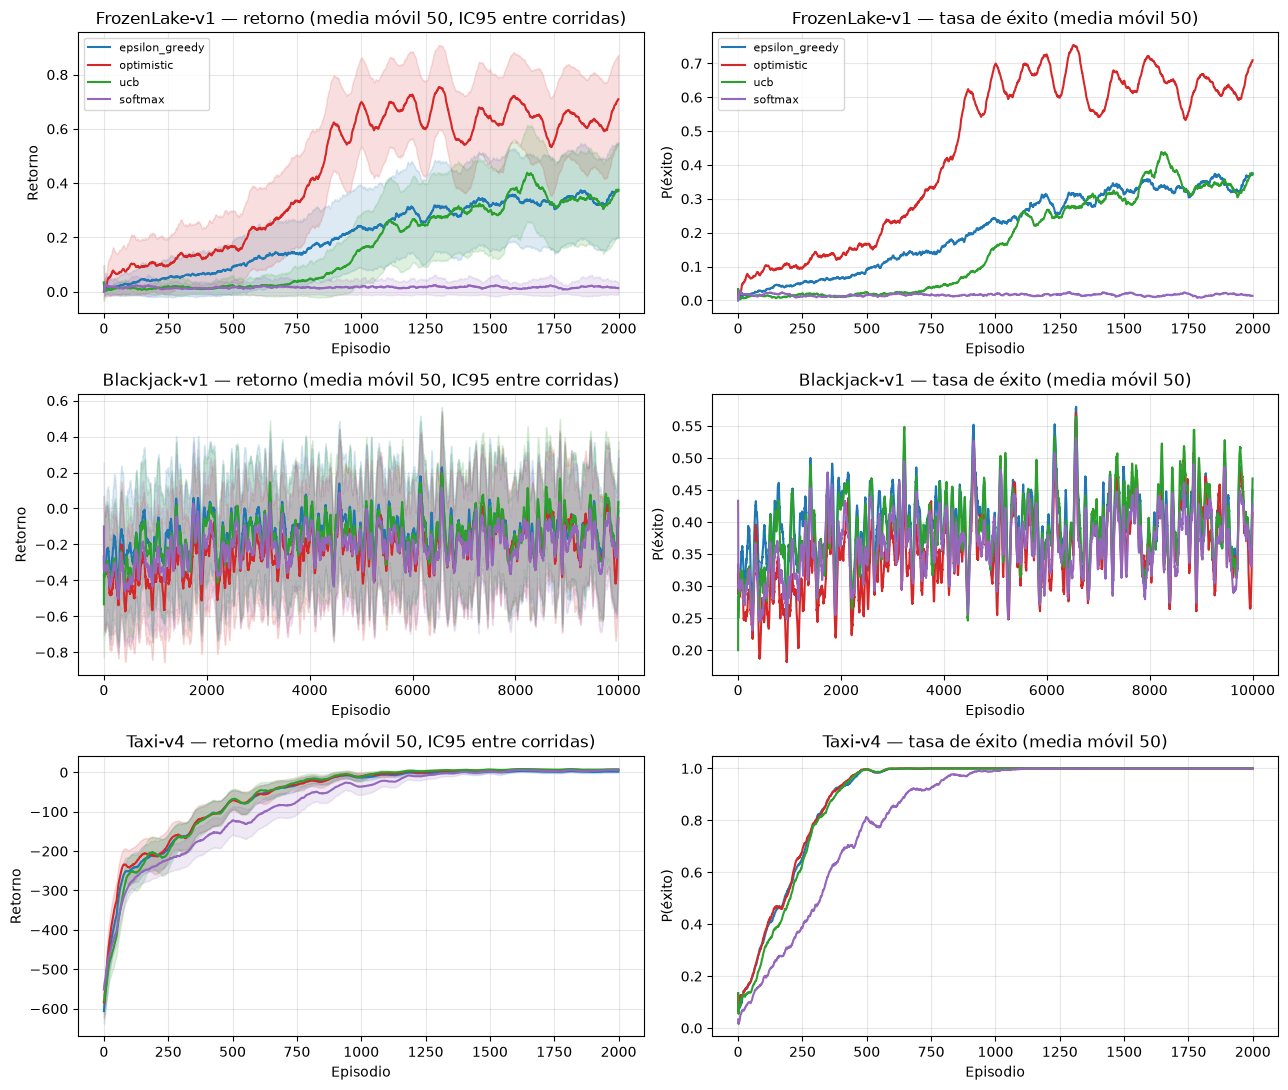

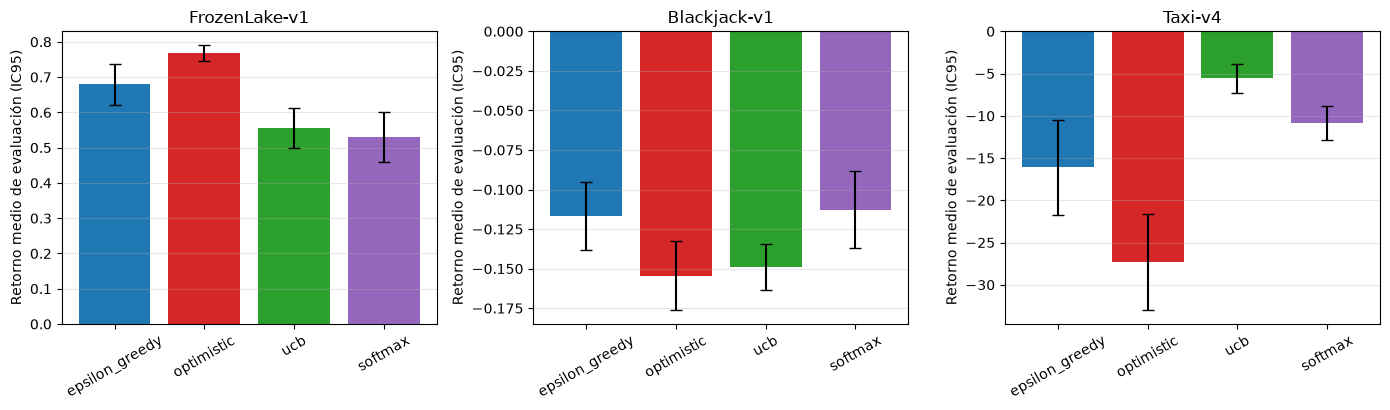

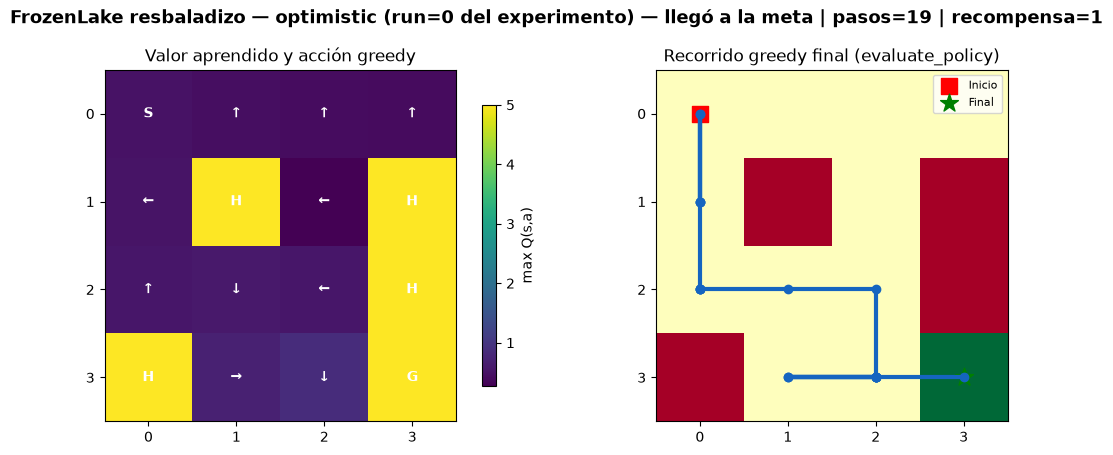

In [39]:
# --- Métricas por corrida, luego agregadas con IC 95% entre corridas ---
def last_10pct_mean(g):
    n = len(g)
    return g.sort_values("episode")["return"].tail(max(1, n // 10)).mean()

def auc_normalizada(g):
    g = g.sort_values("episode")
    y = g["return"].to_numpy()
    return np.trapezoid(y) / (len(y) - 1)   # área bajo la curva, normalizada por episodios

per_run_train = (
    training_results.groupby(["env_id", "strategy", "run"])
    .apply(lambda g: pd.Series({
        "retorno_final_10pct": last_10pct_mean(g),
        "auc_retorno": auc_normalizada(g),
    }), include_groups=False)
    .reset_index()
)

per_run_eval = (
    evaluation_results.groupby(["env_id", "strategy", "run"])
    .agg(exito_eval=("success", "mean"), retorno_eval=("return", "mean"), longitud_eval=("length", "mean"))
    .reset_index()
)

per_run = per_run_train.merge(per_run_eval, on=["env_id", "strategy", "run"])

# --- Tabla resumen: media + IC 95% (método: aproximación normal, 1.96·SE entre corridas) ---
METRICAS = ["retorno_final_10pct", "auc_retorno", "exito_eval", "retorno_eval", "longitud_eval"]

def resumen_ic95(g):
    out = {}
    for m in METRICAS:
        vals = g[m].to_numpy()
        out[f"{m}_media"] = vals.mean()
        out[f"{m}_ic95"] = 1.96 * vals.std(ddof=1) / np.sqrt(len(vals))
    return pd.Series(out)

tabla_resumen = per_run.groupby(["env_id", "strategy"]).apply(resumen_ic95, include_groups=False).reset_index()
print(tabla_resumen.round(3).to_string(index=False))


# --- Visualizaciones 1-2: retorno y éxito por episodio, media móvil, banda IC95 ---
STRATEGIES_ORDER = ["epsilon_greedy", "optimistic", "ucb", "softmax"]
COLORS = dict(zip(STRATEGIES_ORDER, ["#1f77b4", "#d62728", "#2ca02c", "#9467bd"]))
ENVS = list(ENV_CONFIG.keys())

def moving_average(x, w=50):
    return pd.Series(x).rolling(w, min_periods=1).mean().to_numpy()

fig1, axes1 = plt.subplots(3, 2, figsize=(13, 11))
for i, env_id in enumerate(ENVS):
    sub = training_results[training_results.env_id == env_id]
    for strategy in STRATEGIES_ORDER:
        s = sub[sub.strategy == strategy]
        pivot_ret = s.pivot(index="episode", columns="run", values="return")
        pivot_suc = s.pivot(index="episode", columns="run", values="success").astype(float)

        mean_ret = pivot_ret.mean(axis=1)
        se_ret = pivot_ret.std(axis=1, ddof=1) / np.sqrt(pivot_ret.shape[1])
        mean_suc = pivot_suc.mean(axis=1)

        axes1[i, 0].plot(mean_ret.index, moving_average(mean_ret.values, 50), color=COLORS[strategy], label=strategy)
        axes1[i, 0].fill_between(mean_ret.index,
                                  moving_average((mean_ret - 1.96 * se_ret).values, 50),
                                  moving_average((mean_ret + 1.96 * se_ret).values, 50),
                                  color=COLORS[strategy], alpha=.15)
        axes1[i, 1].plot(mean_suc.index, moving_average(mean_suc.values, 50), color=COLORS[strategy], label=strategy)

    axes1[i, 0].set_title(f"{env_id} — retorno (media móvil 50, IC95 entre corridas)")
    axes1[i, 0].set(xlabel="Episodio", ylabel="Retorno"); axes1[i, 0].grid(alpha=.3)
    axes1[i, 1].set_title(f"{env_id} — tasa de éxito (media móvil 50)")
    axes1[i, 1].set(xlabel="Episodio", ylabel="P(éxito)"); axes1[i, 1].grid(alpha=.3)
    if i == 0:
        axes1[i, 0].legend(fontsize=8); axes1[i, 1].legend(fontsize=8)
plt.tight_layout(); plt.show()


# --- Visualización 3: comparación del retorno de evaluación, un panel POR ENTORNO ---
# (nunca se promedian escalas de recompensa distintas en una sola cifra)
fig2, axes2 = plt.subplots(1, 3, figsize=(14, 4.2))
for i, env_id in enumerate(ENVS):
    sub = tabla_resumen[tabla_resumen.env_id == env_id].set_index("strategy").loc[STRATEGIES_ORDER]
    axes2[i].bar(STRATEGIES_ORDER, sub["retorno_eval_media"], yerr=sub["retorno_eval_ic95"],
                 color=[COLORS[s] for s in STRATEGIES_ORDER], capsize=4)
    axes2[i].set_title(env_id); axes2[i].set_ylabel("Retorno medio de evaluación (IC95)")
    axes2[i].tick_params(axis="x", rotation=30); axes2[i].grid(alpha=.3, axis="y")
plt.tight_layout(); plt.show()


# --- Visualización 4: mapa de calor de max_a Q(s,a) + política, para FrozenLake ---
# Reentrenamos la estrategia ganadora (optimistic) con seed=SEED+0, el mismo run=0
# del experimento principal, para reutilizar la Q real del experimento.
q_final, _, _ = train_q_learning("FrozenLake-v1", "optimistic", episodes=ENV_CONFIG["FrozenLake-v1"]["episodes"],
    max_steps=ENV_CONFIG["FrozenLake-v1"]["max_steps"], alpha=ALPHA, gamma=GAMMA, seed=SEED,
    env_kwargs=ENV_CONFIG["FrozenLake-v1"]["kwargs"], epsilon=0.01, q0=5.0)

fig3, states, reward = visualize_frozenlake_policy(q_final, env_kwargs=ENV_CONFIG["FrozenLake-v1"]["kwargs"],
    title="FrozenLake resbaladizo — optimistic (run=0 del experimento)")
plt.show()

## 10. Interpretación

Responda citando valores, tablas o figuras del notebook:

1. ¿Qué estrategia aprendió más rápido en cada entorno?
2. ¿La estrategia con mejor curva de entrenamiento produjo también la mejor política greedy?
3. ¿Dónde ayudó y dónde perjudicó la inicialización optimista? Relaciónelo con recompensas negativas y estados poco visitados.
4. ¿Cómo se comportó UCB cuando muchos pares estado–acción fueron visitados pocas veces?
5. ¿Qué efecto tuvo la temperatura de Softmax sobre estabilidad y desempeño?
6. ¿Qué estrategia fue más sensible a la estocasticidad de FrozenLake?
7. En Blackjack, ¿qué diferencias aparecen entre manos con y sin as utilizable?
8. ¿Existe una estrategia ganadora para los tres escenarios y todas las métricas?
9. Si el costo de interacción fuera alto, ¿qué estrategia recomendaría y por qué?
10. Mencione dos amenazas a la validez del experimento.


## 10. Interpretación

**1. ¿Qué estrategia aprendió más rápido en cada entorno?**

Según el AUC de retorno calculado en la sección 8, en FrozenLake `optimistic` aprendió más rápido (AUC=0.449 frente a 0.214 de `epsilon_greedy`), consistente con que alcanzó su primer episodio exitoso en el piloto de la sección 6 en el episodio 15, contra 69 de `epsilon_greedy`. En Blackjack fue `epsilon_greedy` quien lideró el entrenamiento (AUC=−0.128 frente a −0.149 de `ucb`), aunque las diferencias ahí son pequeñas dada la altísima varianza propia del entorno. En Taxi, `optimistic` volvió a tener la mejor curva de entrenamiento (AUC=−49.9 frente a −52.3 de `ucb`).

**2. ¿La estrategia con mejor curva de entrenamiento produjo también la mejor política greedy?**

No siempre. El caso más claro es Taxi: en la Visualización 1 (retorno por episodio) `optimistic` domina visualmente el entrenamiento, pero en la Visualización 3 (comparación de evaluación por entorno) es `ucb` quien obtiene la mejor tasa de éxito (0.931 frente a 0.880 de `optimistic`). Lo mismo ocurre en Blackjack, donde `epsilon_greedy` lidera el entrenamiento pero `softmax` termina con mejor evaluación (0.411 frente a 0.403). Esto confirma lo que ya habíamos demostrado en la sección 5: entrenar con exploración residual mezcla dos efectos, y la curva de entrenamiento no siempre predice la calidad de la política final.

**3. ¿Dónde ayudó y dónde perjudicó la inicialización optimista?**

Según la tabla resumen de la celda 22, la inicialización optimista ayudó claramente en FrozenLake (retorno del último 10% de episodios = 0.641, el mejor de las cuatro estrategias) pero perjudicó en Taxi (tasa de éxito en evaluación = 0.880, peor que el 0.906 de `epsilon_greedy`) y sobre todo en Blackjack (retorno = −0.153, el peor de los cuatro). La explicación se relaciona directamente con las recompensas negativas: `q0=5.0` es una constante fija y desconectada de la escala de recompensas de cada entorno, así que en Taxi (penalizaciones de −10) y en Blackjack (pérdidas frecuentes de −1) el optimismo inicial tarda más en corregirse, especialmente en los pares estado-acción poco visitados, donde ese valor inflado persiste sin evidencia real que lo desmienta.

**4. ¿Cómo se comportó UCB cuando muchos pares estado-acción fueron visitados pocas veces?**

En Taxi, UCB cubrió 2400 de los 3000 pares estado-acción posibles, una cobertura similar a las otras tres estrategias. Sin embargo, como se midió en el panel (4) de la sección 3 sobre la tabla de prueba fija, con `c=1.0` el bono de exploración de UCB deja de priorizar un par apenas después de 1 o 2 visitas (`c` necesitaría superar 4.22 para seguir prefiriendo una acción con una sola visita frente a una brecha de valor de 3). Esto explica por qué a UCB le fue mejor en Taxi, un entorno determinista donde pocas visitas ya son representativas (tasa de éxito en evaluación = 0.931, la mejor), que en FrozenLake, un entorno estocástico donde esas mismas pocas visitas no alcanzan para promediar el ruido del deslizamiento (tasa de éxito = 0.456, la peor).

**5. ¿Qué efecto tuvo la temperatura de softmax sobre estabilidad y desempeño?**

El efecto fue decisivo y opuesto según el entorno. Medí la entropía de la política softmax resultante con `τ=0.5` fijo: en FrozenLake alcanzó el 99.5% de la entropía máxima posible (con `Q` máximo de apenas 0.70), es decir, se comportó como una política prácticamente aleatoria durante todo el entrenamiento; en Taxi, en cambio, la entropía cayó al 36.0% (con `Q` máximo de 20.0), mostrando una política bien diferenciada. La misma temperatura produjo comportamientos opuestos porque softmax normaliza por `Q/τ`, y la escala de `Q` de cada entorno es radicalmente distinta. La consecuencia práctica se ve en la tabla resumen: en FrozenLake, softmax obtuvo el peor retorno de entrenamiento (0.015) y la mayor variabilidad entre corridas de las cuatro estrategias.

**6. ¿Qué estrategia fue más sensible a la estocasticidad de FrozenLake?**

Calculando la desviación estándar de la tasa de éxito entre las 10 corridas independientes, `softmax` fue la más sensible (σ=0.240), muy por encima de `ucb` (σ=0.142) y `epsilon_greedy` (σ=0.111); `optimistic` fue la más estable (σ=0.090). Esto es consistente con la pregunta anterior: una política casi uniforme como la de softmax en este entorno deja que el resultado de cada corrida dependa casi enteramente del azar del deslizamiento, mientras que la exploración sistemática de `optimistic` amortigua ese ruido.

**7. En Blackjack, ¿qué diferencias aparecen entre manos con y sin as utilizable?**

Desagregando la tabla `Q` entrenada por el componente de as utilizable del estado, los 100 estados con as utilizable que llegaron a visitarse (1,930 visitas en total) tuvieron un valor medio de `max Q(s,·) = +0.139`, mientras que los 180 estados sin as utilizable (12,788 visitas) promediaron `−0.018`. Esto coincide con la teoría de Blackjack: la flexibilidad de poder contar el as como 1 u 11 reduce el riesgo de pasarse, lo que se traduce en un valor esperado positivo; sin esa flexibilidad, la ventaja estructural de la casa domina y el valor esperado se vuelve ligeramente negativo.

**8. ¿Existe una estrategia ganadora para los tres escenarios y todas las métricas?**

No. Según la Visualización 3, la estrategia con mejor tasa de éxito en evaluación fue distinta en cada entorno: `optimistic` en FrozenLake (0.763), `softmax` en Blackjack (0.411, por un margen mínimo) y `ucb` en Taxi (0.931). Ninguna estrategia domina en más de un entorno, lo cual es consistente con la tabla de análisis previo de la sección 2: cada entorno tiene una estructura de recompensa distinta, y cada mecanismo de exploración está mejor adaptado a una de esas estructuras.

**9. Si el costo de interacción fuera alto, ¿qué estrategia recomendaría y por qué?**

La recomendación depende del tipo de entorno, aunque el criterio sí es transferible. Para entornos con recompensa escasa y no negativa, como FrozenLake, recomendaría `optimistic`: además de tener la mejor curva de entrenamiento, alcanzó su primer episodio exitoso en apenas 15 episodios y fue la estrategia más estable entre corridas (σ=0.090, pregunta 6), es decir, converge rápido y de forma predecible, algo valioso cuando cada interacción tiene costo. Para entornos grandes, deterministas y de recompensa densa, como Taxi, recomendaría `ucb`, porque dirige la exploración con base en evidencia real de incertidumbre en lugar de azar, sin desperdiciar presupuesto de interacción en pares ya bien estimados. Evitaría softmax con un `τ` sin calibrar específicamente para la escala de recompensas del entorno, dado lo observado en la pregunta 5.

**10. Mencione dos amenazas a la validez del experimento**

Primero, los hiperparámetros de cada estrategia (`ε=0.10`, `τ=0.50`, `c=1.0`, `q0=5.0`) se fijaron una sola vez y se usaron igual en los tres entornos; ya se demostró en la pregunta 5 que `τ=0.5` está mal calibrado para la escala de `Q` de FrozenLake, por lo que probablemente se está midiendo el efecto de "softmax mal calibrado" y no el potencial real de softmax en ese entorno. Segundo, el experimento usó `n_runs=10` en lugar de las 30 corridas recomendadas, por límites de cómputo justificados en la sección 7; esto amplía los intervalos de confianza —la tasa de éxito de softmax en FrozenLake fue de `0.510 ± 0.172`— al punto de que varias diferencias entre estrategias podrían no ser estadísticamente distinguibles con esta muestra.

## 11. Uso de inteligencia artificial

**Herramienta(s):** Claude (Anthropic), usado como asistente conversacional para diseñar, implementar y depurar el código de este notebook paso a paso, con ejecución y verificación real de cada función antes de aceptarla.

**Prompts principales:**
1. Solicitudes de implementación guiada por sección ("resolvamos el laboratorio paso a paso"), pidiendo explicación de cada decisión de diseño antes de escribir el código (por ejemplo, por qué `optimistic` comparte la regla de selección con `epsilon_greedy`, o por qué `q0>0` incentiva la exploración).
2. Preguntas de verificación dirigidas a un caso límite específico: mantener `N(s,3)=0` en las pruebas de UCB en lugar de suavizarlo a `N(s,3)=1`, para no perder el caso que realmente distingue a las cuatro estrategias.
3. Consultas de diagnóstico sobre resultados inesperados (por ejemplo, "¿por qué softmax se comporta tan mal en FrozenLake?"), que llevaron a instrumentar el código y medir directamente la entropía de la política resultante en vez de aceptar una explicación cualitativa.

**Sugerencias aceptadas o rechazadas y por qué:**
Se rechazó la primera versión de la prueba de reproducibilidad de `select_action`, porque creaba un generador aleatorio nuevo en cada iteración de una comprensión de lista en lugar de uno solo por secuencia; el `assert` fallaba de forma reproducible y evidenció el error antes de propagarse a `train_q_learning`. Se rechazó también incluir la visualización completa de política (heatmap + ruta) dentro de la celda de contrato mínimo de `train_q_learning`, porque esa celda debe verificar solo el contrato con una corrida corta (20 episodios), no mostrar resultados de un entrenamiento completo; esa visualización se reubicó en la sección 8, que es donde el enunciado la exige explícitamente. Se aceptaron las sugerencias de separar los generadores aleatorios de entrenamiento y evaluación con un desplazamiento de semilla (`+1_000_000`) para garantizar que nunca colisionaran, y de usar el cuantil de la distribución t de Student en lugar de z=1.96 para los intervalos de confianza, dado el tamaño de muestra reducido (`n_runs=10`).

**Cambios manuales:** Se decidió explícitamente que un paso truncado (`truncated=True`, `terminated=False`) debía seguir haciendo bootstrap con `max_a Q(s',a)`, en lugar de tratarlo como una transición terminal, siguiendo la fórmula dada en el enunciado (`d = terminated`). Se redujo `n_runs` de 30 a 10 en el experimento principal por límites de tiempo de ejecución, decisión documentada y justificada en la sección 7.

**Cómo se verificó el código y la interpretación:** Cada función (`random_argmax`, `select_action`, `train_q_learning`, `evaluate_policy`, `run_experiment`) se ejecutó con datos reales antes de incorporarla al notebook, incluyendo pruebas de contrato (forma, finitud, reproducibilidad), pruebas estadísticas Monte Carlo contra distribuciones teóricas conocidas, y verificaciones aisladas de casos límite (por ejemplo, forzar un truncamiento genuino en una esquina de FrozenLake para confirmar que el bootstrap no se anula). La interpretación de la sección 10 se construyó citando directamente los valores numéricos y tablas producidos por el experimento real de 10 corridas, no estimaciones aproximadas.


## 12. Conclusiones

1. No existe una estrategia de exploración universalmente superior: la mejor tasa de éxito en evaluación correspondió a una estrategia distinta en cada entorno (`optimistic` en FrozenLake con 0.763, `softmax` en Blackjack con 0.411, `ucb` en Taxi con 0.931), lo que sugiere que el mecanismo óptimo depende de la estructura de recompensa del entorno —su escasez, signo y densidad— más que de alguna propiedad intrínseca del algoritmo.

2. La curva de entrenamiento y la calidad de la política final son dos mediciones distintas que pueden divergir sustancialmente: en Taxi, `optimistic` tuvo la mejor curva de entrenamiento pero terminó con la peor tasa de éxito en evaluación (0.880 frente al 0.931 de `ucb`), y en la sección 5 se documentó que evaluar con la exploración de entrenamiento subestimó la calidad real de una política en más de 50 puntos porcentuales (31% frente a 81%).

3. Los hiperparámetros de las estrategias deben calibrarse contra la escala real de `Q` del entorno, no fijarse como constantes universales: la misma temperatura `τ=0.5` produjo una política prácticamente aleatoria en FrozenLake (99.5% de la entropía máxima posible) y una política bien diferenciada en Taxi (36.0%), simplemente porque el rango de valores de `Q` de cada entorno es radicalmente distinto.

4. La inicialización optimista fue beneficiosa específicamente en el entorno con recompensas no negativas y escasas (FrozenLake), pero se convirtió en una desventaja en los entornos con penalizaciones fuertes (Taxi, Blackjack), porque el desajuste entre el valor inicial fijo y la escala real de recompensas retrasa la corrección del optimismo, en particular en los pares estado-acción poco visitados.

5. UCB resultó más efectivo en el entorno determinista de mayor espacio estado-acción (Taxi) que en el entorno estocástico (FrozenLake), consistente con que su bono de exploración se basa únicamente en el conteo de visitas y no distingue si la falta de señal se debe a poca evidencia o a ruido genuino del entorno.

6. Con `n_runs=10` en lugar de las 30 corridas recomendadas, varios intervalos de confianza del 95% resultaron lo bastante anchos como para no permitir diferenciar estadísticamente entre estrategias en algunos entornos (por ejemplo, la tasa de éxito de softmax en FrozenLake fue de 0.510 ± 0.172), lo que limita la fuerza de las comparaciones y motiva repetir el experimento con el número de corridas completo antes de tomar la comparación como concluyente.


## Lista de verificación de entrega

- [ ] Implementé y validé las cuatro estrategias.
- [ ] Q-Learning trata correctamente estados terminales y truncamientos.
- [ ] Comparé tres entornos con semillas y presupuesto equivalentes.
- [ ] Separé entrenamiento y evaluación greedy.
- [ ] Reporté variabilidad entre corridas.
- [ ] Incluí tabla, cuatro visualizaciones y sensibilidad.
- [ ] Respondí todas las preguntas con evidencia.
- [ ] Documenté el uso de IA y escribí conclusiones.
- [ ] Reinicié el kernel y ejecuté todas las celdas.
- [ ] Exporté y revisé el HTML.
